# Imports

In [1]:
# -------------------------------------------------------------------
# IPython autoreload (development convenience)
# -------------------------------------------------------------------
%load_ext autoreload
%autoreload 2

# -------------------------------------------------------------------
# Warnings configuration
# -------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------------------------------------------------------
# Standard library
# -------------------------------------------------------------------
import sys  # file management, path manipulation


# -------------------------------------------------------------------
# Scientific computing / data analysis
# -------------------------------------------------------------------
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

from scipy import stats
from scipy.stats import t
# -------------------------------------------------------------------
# Plotting and visualization
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
plt.rcParams["mathtext.fontset"] = "dejavusans"
import string  # for subplot lettering, etc.

# -------------------------------------------------------------------
# Project‑local modules
# -------------------------------------------------------------------
import config
import coords
from load_aquaplanet_data import load_multi_experiment_processed_data

# -------------------------------------------------------------------
# Auxiliary project utilities
# -------------------------------------------------------------------
from auxiliary_functions import xarray_utils
from auxiliary_functions.plotting_utils import (
    bmh_colors,
    tick_labeller,
    set_plot_mode,
    get_figsize,
)

# -------------------------------------------------------------------
# Logging configuration
# -------------------------------------------------------------------
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)
logger = logging.getLogger(__name__)
logger.info("Imports loaded")

/glade/u/home/sressel/thesis-work/python/auxiliary_functions/src/auxiliary_functions/__init__.py:49: UserWarning: Could not import from calculate_velocity_potential (likely missing 'windspharm'): No module named 'windspharm'
  warnings.warn(f"Could not import from calculate_velocity_potential (likely missing 'windspharm'): {e}")
2026-08-04 12:29:15,962 [INFO] Imports loaded


# Load Data

In [21]:
variables_to_load = [
    "Precipitation",
    "Outgoing Longwave Radiation",
    # "Zonal Wind",
    # "Meridional Wind",
    # "Vertical Wind",
    # "Divergence",
    "Temperature",
    # "Moisture",
    # "Relative Humidity",
    # "Geopotential Height",
    # "Longwave Heating Rate",
    # "Shortwave Heating Rate",
    # "Latent Heat Flux",
    # "Sensible Heat Flux",
    # "Surface Pressure",
    # "Moist Static Energy",
    # "Dry Static Energy",
    # "Column Moist Static Energy",
    # "Column Water Vapor",
    # "Column Temperature",
    # "Column Longwave Heating",
    # "Column Shortwave Heating",
    # "Potential Temperature",
    # "Saturation Specific Humidity"
    # "Column Relative Humidity",
    # "Diabatic Heating",
    # "Chikira alpha"
    # "Surface Longwave Flux",
    # "Surface Shortwave Flux",
    # "TOA Longwave Flux",
    # "TOA Shortwave Flux",
    # "Net Longwave Flux",
    # "Net Shortwave Flux",
    "Cloud Ice Water Content",
    "Cloud Liquid Water Content",
    "Cloud Fraction",
    "Cloud Ice Water Path",
]

# Subset data

In [22]:
# Check if the subset has already been loaded
if not 'multi_experiment_variables_subset' in locals():
    # If not loaded yet, load the multi-experiment data with variables subset
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset'
    )
else:
    # If already loaded, reload the data while preserving the existing subset
    # and pass False to prevent overwriting
    multi_experiment_variables_subset = load_multi_experiment_processed_data(
        variables_to_load,
        'subset',
        multi_experiment_variables_subset,
        False
    )

2026-08-04 12:47:28,131 [INFO] Loading subset data
2026-08-04 12:47:28,132 [INFO] (1/7) Precipitation...
2026-08-04 12:47:28,133 [INFO] (2/7) Outgoing Longwave Radiation...
2026-08-04 12:47:28,133 [INFO] (3/7) Temperature...
2026-08-04 12:47:28,134 [INFO]     Experiment: -4K...
2026-08-04 12:47:28,227 [INFO]     Experiment: 0K...
2026-08-04 12:47:28,312 [INFO]     Experiment: 4K...
2026-08-04 12:47:41,523 [INFO] (4/7) Cloud Ice Water Content...
2026-08-04 12:47:41,525 [INFO] (5/7) Cloud Liquid Water Content...
2026-08-04 12:47:41,525 [INFO] (6/7) Cloud Fraction...
2026-08-04 12:47:41,526 [INFO] (7/7) Cloud Ice Water Path...
2026-08-04 12:47:41,527 [INFO] Finished


# Temperature-level interpolation

In [4]:
# Define a function that interpolates a variable to a specific temperature level
def temperature_level_interpolation(variable_to_interpolate, interpolation_temperature):

    if 'Temperature' not in multi_experiment_variables_subset:
        raise KeyError("'Temperature' not found in 'multi_experiment_variables_subset'")

    # If the variable is a cloud-related property, select temperature data excluding the first time step
    # Otherwise, use the full temperature dataset
    if variable_to_interpolate.name in ['Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Fraction', 'Cloud Condensate']:
        temperature_array = multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None))
    else:
        temperature_array = multi_experiment_variables_subset['Temperature']

    # Create a boolean mask identifying where temperature exceeds the interpolation threshold
    interpolation_mask = temperature_array > interpolation_temperature
    # Find the index of the first pressure level where temperature exceeds the threshold (argmax returns first True)
    index_of_interpolation_temperature = interpolation_mask.argmax(dim='plev')                
    
    # Extract the pressure level at the warmer (first exceeding) temperature threshold
    # Where no threshold is exceeded, the value is set to NaN via the where() condition
    warmer_pressure_level = temperature_array['plev'].isel(plev=index_of_interpolation_temperature).where(interpolation_mask.any(dim='plev')) 
    # Extract the pressure level just below the threshold (one level colder)
    colder_pressure_level = temperature_array['plev'].isel(plev=index_of_interpolation_temperature-1).where(interpolation_mask.any(dim='plev'))     

    # Get the actual temperature values at the warmer pressure level for use in interpolation
    temperature_at_warmer_pressure_level = temperature_array.sel(plev=warmer_pressure_level)
    # Get the actual temperature values at the colder pressure level for use in interpolation
    temperature_at_colder_pressure_level = temperature_array.sel(plev=colder_pressure_level)

    # Get the variable values at the warmer pressure level
    variable_at_warmer_pressure_level = variable_to_interpolate.sel(plev=warmer_pressure_level)
    # Get the variable values at the colder pressure level
    variable_at_colder_pressure_level = variable_to_interpolate.sel(plev=colder_pressure_level)

    # Perform linear interpolation to find the pressure level at the exact interpolation temperature
    # Formula: plev = plev_warm + (plev_cold - plev_warm) * (T_interp - T_warm) / (T_cold - T_warm)
    plev_at_interpolation_temperature = (
        warmer_pressure_level 
        + (colder_pressure_level - warmer_pressure_level)*(interpolation_temperature - temperature_at_warmer_pressure_level)/(temperature_at_colder_pressure_level - temperature_at_warmer_pressure_level)
    )

    # Perform linear interpolation to find the variable value at the exact interpolation temperature
    # Uses the same linear interpolation principle applied to the variable of interest
    variable_at_interpolation_temperature = (
        variable_at_warmer_pressure_level 
        + (variable_at_colder_pressure_level - variable_at_warmer_pressure_level)*(plev_at_interpolation_temperature - warmer_pressure_level)/(colder_pressure_level - warmer_pressure_level)
    )

    # Return the interpolated variable value at the specified temperature level
    return plev_at_interpolation_temperature, variable_at_interpolation_temperature

In [ ]:
# logger.info("Interpolating variable to 220K level...")
# _, cloud_ice_water_content_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Ice Water Content'], 220)
# cloud_ice_water_content_at_220K.name = 'Cloud Ice Water Content at 220K'
# cloud_ice_water_content_at_220K.attrs['units'] = 'g m$^{-2}$'

# _, cloud_liquid_water_content_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Liquid Water Content'], 220)
# cloud_liquid_water_content_at_220K.name = 'Cloud Liquid Water Content at 220K'
# cloud_liquid_water_content_at_220K.attrs['units'] = 'g m$^{-2}$'

_, cloud_fraction_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Fraction'], 220)
cloud_fraction_at_220K.name = 'Cloud Fraction at 220K'
cloud_fraction_at_220K.attrs['units'] = ''

# Joint Histograms

## Calculate

In [17]:
# Analysis parameters
remove_climatology = True
center_on_zero = False
estimate_slope = True

N = np.size(multi_experiment_variables_subset['Precipitation'].sel(experiment='4K').values)
t_critical = t.ppf(0.95, df=N-2)

#### Specify numerator variable
# numerator_variable = cloud_fraction_at_220K
# numerator_variable = multi_experiment_variables_subset['Cloud Ice Water Path']
# numerator_variable = multi_experiment_variables_subset['Cloud Liquid Water Path']
# numerator_variable = multi_experiment_variables_subset['Total Column Water']
# numerator_variable = multi_experiment_variables_subset['Total Cloud Condensate']
numerator_variable = multi_experiment_variables_subset['Outgoing Longwave Radiation']
# numerator_variable = 1000*cloud_liquid_water_content_at_220K

#### Specify denominator variable
# denominator_variable = multi_experiment_variables_subset['Cloud Ice Water Path']
# denominator_variable = multi_experiment_variables_subset['Cloud Liquid Water Path']
denominator_variable = multi_experiment_variables_subset['Precipitation'].units.to_energy_units()
# denominator_variable = (1/1000)*config.LIQUID_WATER_DENSITY*multi_experiment_variables_subset['Column Water Vapor']
# denominator_variable.attrs['units'] = 'g m$^{-2}$'
# denominator_variable = multi_experiment_variables_subset['Total Cloud Condensate']
# denominator_variable = multi_experiment_variables_subset['Total Column Water']
# denominator_variable = cloud_ice_water_content_at_220K

logger.info(f"Numerator: {numerator_variable.name}")
logger.info(f"Denominator: {denominator_variable.name}")

if remove_climatology:
    logger.info("Removing climatology")
    numerator_variable = numerator_variable.stats.standardize(dim='time', zero_mean=True, unit_variance=False)
    denominator_variable = denominator_variable.stats.standardize(dim='time', zero_mean=True, unit_variance=False)

numerator_variable = numerator_variable.where(coords.latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))
denominator_variable = denominator_variable.where(coords.latitude_mask, drop=True).stack(grid_points=(['time', 'lat', 'lon']))

slope_estimate = xr.zeros_like(coords.experiments).astype('float64')
intercept_estimate = xr.zeros_like(coords.experiments).astype('float64')

if center_on_zero:
    logger.info("Centering histogram on origin")
    denominator_variable = denominator_variable.stats.standardize(dim='grid_points', zero_mean=True, unit_variance=False)
    numerator_variable = numerator_variable.stats.standardize(dim='grid_points', zero_mean=True, unit_variance=False)

mask = ~np.isnan(denominator_variable) & ~np.isnan(numerator_variable)
numerator_variable = numerator_variable.where(mask)
denominator_variable = denominator_variable.where(mask)

counts,xedges,yedges = {}, {}, {}
logger.info("Calculating bins and counts")
for index, experiment in enumerate(coords.experiments.values):
    logger.info(f"    Experiment {config.EXPERIMENT_DISPLAY_NAMES[experiment]}...")

    denominator_masked_by_experiment = denominator_variable.sel(experiment=experiment).dropna(dim='grid_points')
    numerator_masked_by_experiment = numerator_variable.sel(experiment=experiment).dropna(dim='grid_points')

    counts[experiment],xedges[experiment],yedges[experiment] = np.histogram2d(
        x=denominator_masked_by_experiment,
        y=numerator_masked_by_experiment,
        bins=[100, 100],
    )

    # Estimate slope & intercept of best-fit line
    if estimate_slope:
        slope_estimate[index], intercept_estimate[index] = np.polyfit(
            y=numerator_masked_by_experiment,
            x=denominator_masked_by_experiment,
            deg=1
        )
        # predicted_value = slope_estimate[index] * denominator_variable.sel(experiment=experiment).where(mask, drop=True)

logger.info("Finished")

2026-08-04 12:43:29,042 [INFO] Numerator: Outgoing Longwave Radiation
2026-08-04 12:43:29,044 [INFO] Denominator: Precipitation
2026-08-04 12:43:29,045 [INFO] Removing climatology
2026-08-04 12:43:34,931 [INFO] Calculating bins and counts
2026-08-04 12:43:34,932 [INFO]     Experiment −4K...
2026-08-04 12:43:36,050 [INFO]     Experiment CTRL...
2026-08-04 12:43:37,162 [INFO]     Experiment +4K...
2026-08-04 12:43:38,176 [INFO] Finished


In [43]:
multi_experiment_variables_subset['Precipitation'].to_netcdf("/glade/u/home/sressel/spencer-scratch/aquaplanet_data_for_zenodo/multi_experiment_variables_subset_PRCP.nc")

## Plot

/glade/derecho/scratch/sressel/tmp/ipykernel_103392/1735860983.py:27: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_103392/1735860983.py:48: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_103392/1735860983.py:27: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_103392/1735860983.py:48: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_103392/1735860983.py:27: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
/glade/derecho/scratch/sressel/tmp/ipykernel_103392/1735860983.py:48: RuntimeWarning: divide by zero encountered in log10
  np.log10(counts[experiment].transpose()),
2026

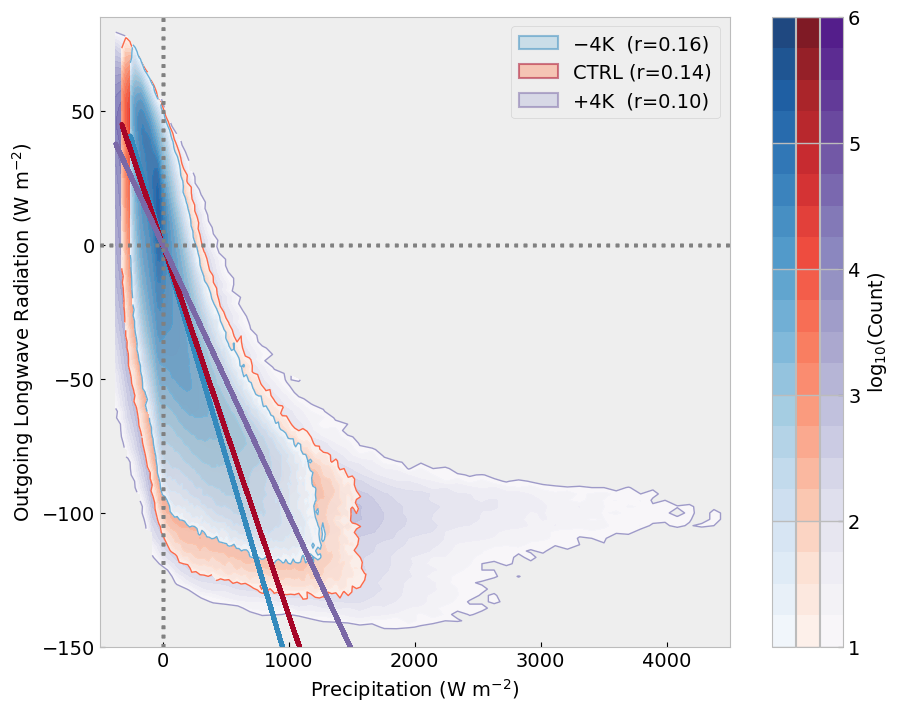

In [18]:
SAVE_FIG = True
PLOT_MODE = "slides"
FIG_LAYOUT = 'full'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = fig.add_gridspec(1, 2, wspace=0.1, width_ratios=[0.9, 1-0.9])
gs.update(left=0.05, right=0.8, bottom=0.05, top=0.95)

ax = fig.add_subplot(gs[0])

gs_cbars = gs[1].subgridspec(1, 3, wspace=0.05)
cbar_axes = [
    fig.add_subplot(gs_cbars[0]),
    fig.add_subplot(gs_cbars[1]),
    fig.add_subplot(gs_cbars[2]),
]

# Create legend with median color for each experiment
legend_elements = []

# ax.set_title(f'{string.ascii_letters[ax_index]}) {dict_name}', loc='left', pad=5, fontsize=fontsize+2)
for index, experiment in enumerate(coords.experiments.values):
    im = ax.contourf(
        np.log10(counts[experiment].transpose()),
        extent=[xedges[experiment][0],xedges[experiment][-1],yedges[experiment][0],yedges[experiment][-1]],
        cmap=config.EXPERIMENT_CMAPS[experiment],
        levels=np.linspace(np.log10(10), 6, 21),
        alpha=0.9,
        zorder = 4-index,
    )

    legend_elements.append(
        plt.Rectangle(
            (0, 0), 1, 1,
            facecolor=plt.get_cmap(config.EXPERIMENT_CMAPS[experiment])(0.35),
            edgecolor=bmh_colors(index+1),
            alpha=0.5,
            linewidth=1.5,
            label=f"{config.EXPERIMENT_DISPLAY_NAMES[experiment]:<4} (r={-slope_estimate.sel(experiment=experiment):>1.2f})",
            # label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
            )
        )

    ax.contour(
        np.log10(counts[experiment].transpose()),
        extent=[xedges[experiment][0],xedges[experiment][-1],yedges[experiment][0],yedges[experiment][-1]],
        levels = [im.levels[0]],
        colors = plt.get_cmap(config.EXPERIMENT_CMAPS[experiment])(0.5),
        # colors=bmh_colors(index+1),
        zorder = 4-index,
        linewidths=1
    )

    denominator_masked_by_variable = denominator_variable.sel(experiment=experiment).dropna(dim='grid_points')
    ax.plot(
            denominator_masked_by_variable,
            slope_estimate.sel(experiment=experiment).values*denominator_masked_by_variable+intercept_estimate.sel(experiment=experiment).values,
            color=bmh_colors(index+1),
            lw=3,
            label=f"{config.EXPERIMENT_DISPLAY_NAMES[experiment]:<4} (r={-slope_estimate.sel(experiment=experiment):>1.2f})",
            zorder=10,
        )

    ax.axhline(y=0, color='gray', ls=':', zorder=10)
    ax.axvline(x=0, color='gray', ls=':', zorder=10)

    cbar = fig.colorbar(im, cax=cbar_axes[index])
    [cbar.ax.axhline(y=val, color='#bcbcbc', lw=1) for val in np.arange(1, 7, 1)]
    if experiment == '4K':
        cbar.set_ticks(np.arange(1, 7, 1))
        cbar.set_label(r"log$_{10}$(Count)")
    else:
        cbar.set_ticks([])

ax.grid(False)
ax.set_xlabel(f"{denominator_variable.name} ({denominator_variable.attrs['units']})")
ax.set_ylabel(f"{numerator_variable.name} ({numerator_variable.attrs['units']})")

# ax.set_xlim(0, 1.1*denominator_variable.max())
# ax.set_ylim(0, 1.1*numerator_variable.max())

# ax.set_xlim(0, 825)
# ax.set_ylim(0, 55)

ax.set_xlim(-500, 4500)
ax.set_ylim(-150, 85)

ax.set_aspect((ax.get_xlim()[1] - ax.get_xlim()[0])/(ax.get_ylim()[1] - ax.get_ylim()[0]))
ax.legend(handles=legend_elements, loc='upper right')

# Save figure
output_filename = f"{numerator_variable.name}{(' Anomalies' if remove_climatology else '')} & {denominator_variable.name}{(' Anomalies' if remove_climatology else '')} - Log(Histogram)"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.pdf",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

# Calculate CIWP Percentiles

In [19]:
stacked_cloud_ice_water_path = multi_experiment_variables_subset['Cloud Ice Water Path'].stack(samples=("time", "lat", "lon"))
ranks = stacked_cloud_ice_water_path.argsort(axis=1).argsort(axis=1)
stacked_percentiles = ranks / (stacked_cloud_ice_water_path.sizes["samples"] - 1)
cloud_ice_water_path_percentiles = stacked_percentiles.unstack('samples')
# cloud_ice_water_path_percentile_bins = np.arange(0, 1.025, 0.025)
cloud_ice_water_path_percentile_bins = np.linspace(0, 1, 51)

# Bin Variables

In [31]:
binning_variable_by_temperature = {}

recalculate = True
normalize_binning_variable = True

temperature_bins = np.arange(180, 320, 5)  # adjust as needed
# bins = np.arange(200, 240, 4)  # adjust as needed

# print("Bin Variables by Temperature")
logger.info("Bin Variables by Temperature")
for binning_variable in [
    # 'Clear Sky Radiative Cooling',
    'Cloud Ice Water Content',
    # 'Divergence',
    # 'Cloud Fraction',
    # 'Cloud Condensate',
    # 'Relative Humidity'
]:
    binning_variable_by_temperature[binning_variable] = xr.DataArray(
        data = np.zeros((len(coords.experiments), len(temperature_bins[:-1]))),
        dims=['experiment', 'temperature'],
        coords={'experiment':coords.experiments, 'temperature':temperature_bins[:-1]}
    )
    logger.info("=" * config.SEP_WIDTH)
    logger.info(f"{binning_variable}...")

    if 'binning_variable_by_temperature' not in locals() or recalculate:

        for index, experiment in enumerate(coords.experiments.values):

            if binning_variable in ['Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Condensate']:
                temperature = multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(
                    experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
                )

            else:
                temperature = multi_experiment_variables_subset['Temperature'].sel(
                    experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
                )

            binning_variable_subset = multi_experiment_variables_subset[binning_variable].sel(
                experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
            )

            temperature_flat = temperature.values.flatten()
            binning_variable_flat = binning_variable_subset.values.flatten()

            mask = np.isfinite(temperature_flat) & np.isfinite(binning_variable_flat)

            temperature_flat = temperature_flat[mask]
            binning_variable_flat = binning_variable_flat[mask]

            digitized = np.digitize(temperature_flat, temperature_bins)

            binning_variable_by_temperature[binning_variable][index, :] = [
                np.nanmean(binning_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(temperature_bins))
            ]

    logger.info("✔ Done")

logger.info("=" * config.SEP_WIDTH)
logger.info("Finished")

2026-08-04 12:52:39,159 [INFO] Bin Variables by Temperature
2026-08-04 12:52:39,166 [INFO] ========================================
2026-08-04 12:52:39,170 [INFO] Cloud Ice Water Content...
2026-08-04 12:53:16,950 [INFO] ✔ Done
2026-08-04 12:53:16,952 [INFO] ========================================
2026-08-04 12:53:16,953 [INFO] Finished


2026-08-04 12:53:16,999 [INFO] Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//
2026-08-04 12:53:17,000 [INFO] Output filename: Cloud Ice Water Content by Temperature - High OLR
2026-08-04 12:53:17,001 [INFO] Not saving


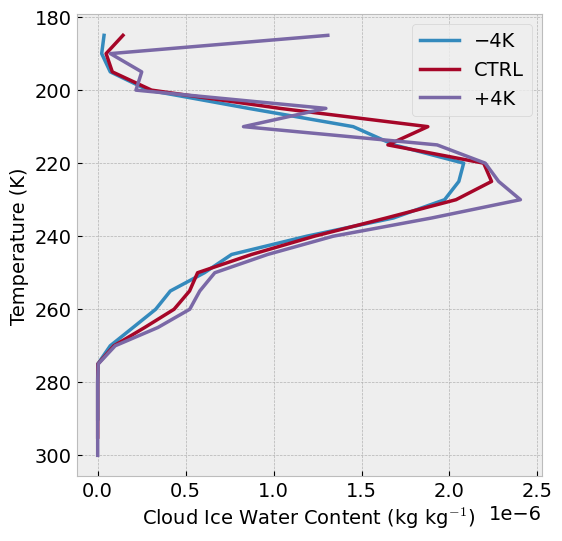

In [32]:
binning_variable_to_plot = 'Cloud Ice Water Content'
# binning_variable_to_plot = 'Cloud Condensate'
# binning_variable_to_plot = 'Divergence'
# binning_variable_to_plot = 'Cloud Fraction'
# binning_variable_to_plot = 'Relative Humidity'

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'square'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)

[fig, ax] = plt.subplots(
    figsize=get_figsize(PLOT_MODE, FIG_LAYOUT)
)

for index, experiment in enumerate(coords.experiments.values):
    ax.plot(
        (
            binning_variable_by_temperature[binning_variable_to_plot].sel(experiment=experiment)
            # / binning_variable_by_temperature[binning_variable_to_plot].sel(experiment=experiment).max(dim=['temperature'])
        ),
        # np.gradient(binning_variable_by_temperature[experiment], bins[:-1]),
        binning_variable_by_temperature[binning_variable_to_plot].temperature,
        color=bmh_colors(index+1),
        label = config.EXPERIMENT_DISPLAY_NAMES[experiment],
    )

# ax.set_xlabel(
#     f"{('Normalized' if binning_variable_by_temperature[binning_variable_to_plot].attrs['normalized'] else '')} \n{binning_variable_to_plot}"
#     f" ({(multi_experiment_variables_subset[binning_variable_to_plot].attrs['units'] if not binning_variable_by_temperature[binning_variable].attrs['normalized'] else '')})",
# )
# ax.set_xlabel(
#     f"Normalized \n{binning_variable_to_plot}",
# )
ax.set_xlabel(
    f"{binning_variable_to_plot} ({multi_experiment_variables_subset[binning_variable_to_plot].attrs['units']})",
)
ax.set_ylabel("Temperature (K)")
ax.legend(loc='best')
ax.invert_yaxis()

output_filename = f"{binning_variable_to_plot} by Temperature - High OLR"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

## Emissivity

In [ ]:
ice_water_path_layer = (25*100/9.8)*multi_experiment_variables_subset['Cloud Ice Water Content']
liquid_water_path_layer = (25*100/9.8)*multi_experiment_variables_subset['Cloud Liquid Water Content']

# tau_lw_layer = 0.08*1000*liquid_water_path_layer + 0.04*1000*ice_water_path_layer
tau_lw_layer = 1*1000*liquid_water_path_layer + 1*1000*ice_water_path_layer
tau_lw = tau_lw_layer.sum(dim='plev')
emissivity = 1 - np.exp(-tau_lw)

multi_experiment_variables_subset['Emissivity'] = emissivity

binning_variable_by_emissivity = {}

recalculate = True
normalize_binning_variable = True

# bins = np.arange(180, 320, 5)  # adjust as needed
bins = np.arange(0.01, 1.05, 0.05)
# bins = np.arange(200, 240, 4)  # adjust as needed

print("Bin Variables by Emissivity")
for binning_variable in [
    # 'Clear Sky Radiative Cooling',
    # 'Cloud Ice Water Content',
    # 'Divergence',
    # 'Cloud Fraction',
    'Outgoing Longwave Radiation',
    # 'Relative Humidity'
]:
    binning_variable_by_emissivity[binning_variable] = xr.DataArray(
        data = np.zeros((3, len(bins[:-1]))),
        dims=['experiment', 'emissivity'],
        coords={'experiment':experiments_array, 'emissivity':bins[:-1]}
    )
    print(f"{'='*config.SEP_WIDTH}")
    print(f"{f'{binning_variable}...':<{config.SEP_WIDTH}}")
    if 'binning_variable_by_emissivity' not in locals() or recalculate:

        for index, experiment in enumerate(experiments_list):
            
            domain_mean_emissivity = multi_experiment_variables_subset['Emissivity'].sel(
                experiment=experiment, lat=slice(-15,15)
            )#.mean(dim=['lat', 'lon'])
            emissivity_flat = domain_mean_emissivity.values.flatten()

            # domain_mean_binning_variable = standardize_data(multi_experiment_variables_subset[binning_variable], 'time', False).sel(
            #     experiment=experiment, lat=slice(-15,15)
            # ).isel(time=slice(1, None))
            domain_mean_binning_variable = multi_experiment_variables_subset[binning_variable].sel(
                experiment=experiment, lat=slice(-15,15)
            ).isel(time=slice(1, None))
        
            binning_variable_flat = domain_mean_binning_variable.values.flatten()

            mask = np.isfinite(emissivity_flat) & np.isfinite(binning_variable_flat)

            emissivity_flat = emissivity_flat[mask]
            binning_variable_flat = binning_variable_flat[mask]

            # emissivity bins
            digitized = np.digitize(emissivity_flat, bins)

            binning_variable_by_emissivity[binning_variable][index, :] = [
                np.nanmean(binning_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(bins))
            ]

    print(rf"{'✔':>1}")

print(f"{'='*config.SEP_WIDTH}")
print("Finished")

In [ ]:
# binning_variable_to_plot = 'Cloud Ice Water Content'
binning_variable_to_plot = 'Outgoing Longwave Radiation'
# binning_variable_to_plot = 'Divergence'
# binning_variable_to_plot = 'Cloud Fraction'
# binning_variable_to_plot = 'Relative Humidity'

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'square'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)

[fig, ax] = plt.subplots(
    figsize=get_figsize(PLOT_MODE, FIG_LAYOUT)
)

for index, experiment in enumerate(experiments_list):
    ax.plot(
        binning_variable_by_emissivity[binning_variable_to_plot].emissivity,
        (
            binning_variable_by_emissivity[binning_variable_to_plot].sel(experiment=experiment)
            # / binning_variable_by_emissivity[binning_variable_to_plot].sel(experiment=experiment).max(dim=['emissivity'])
            # / binning_variable_by_emissivity[binning_variable_to_plot].sel(experiment=experiment).isel(emissivity=-1)
        ),
        color=bmh_colors(index+1),
        label = experiments_array.sel(experiment=experiment)['name'].item(),
    )
    ax.axvline(
        emissivity.sel(experiment=experiment).mean(dim=['time', 'lat', 'lon']),
        color=bmh_colors(index+1),
        ls='--',
        lw=1,
        # label=f"{experiments_array.sel(experiment=experiment)['name'].item()} Mean Emissivity"
        )

# ax.set_xlabel(
#     f"{('Normalized' if binning_variable_by_temperature[binning_variable_to_plot].attrs['normalized'] else '')} \n{binning_variable_to_plot}"
#     f" ({(multi_experiment_variables_subset[binning_variable_to_plot].attrs['units'] if not binning_variable_by_temperature[binning_variable].attrs['normalized'] else '')})",
# )
# ax.set_xlabel(
#     f"Normalized \n{binning_variable_to_plot}",
# )
ax.set_ylabel(
    f"{binning_variable_to_plot} ({multi_experiment_variables_subset[binning_variable_to_plot].attrs['units']})",
)
ax.set_xlabel("Emissivity")
ax.set_xlim(0, 1)
ax.legend(loc='best')

output_filename = f'Normalized {binning_variable_to_plot} by Emissivity'
print(f"Output directory: {aquaplanet_output_directory}/mean-state/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{aquaplanet_output_directory}/mean-state/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
# if 'clear_sky_radiative_cooling' not in locals():
#     cloud_condensate_specific_humidity = multi_experiment_variables_subset['Cloud Ice Water Content'] + multi_experiment_variables_subset['Cloud Liquid Water Content']
#     cloudy_cells = cloud_condensate_specific_humidity > 1e-5
#     clear_sky_cells = cloud_condensate_specific_humidity <= 1e-5
#     clear_sky_radiative_cooling = multi_experiment_variables_subset['Longwave Heating Rate'].where(clear_sky_cells)
#     clear_sky_radiative_cooling.sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'], skipna=True).plot(y='plev', yincrease=False, hue='experiment')

#     multi_experiment_variables_subset['Clear Sky Radiative Cooling'] = clear_sky_radiative_cooling
#     multi_experiment_variables_subset['Clear Sky Radiative Cooling'].attrs['units'] = r'W m$^{-2}$'

# multi_experiment_variables_subset['Cloud Condensate'] = (
#     multi_experiment_variables_subset['Cloud Ice Water Content'] + multi_experiment_variables_subset['Cloud Liquid Water Content']
# )

# olr_mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.05, dim=['time', 'lat', 'lon'])
# )

olr_mask = (
    multi_experiment_variables_subset['Outgoing Longwave Radiation']
    >= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.8, dim=['time', 'lat', 'lon'])
)

binning_variable_by_precipitation = {}

recalculate = True
normalize_binning_variable = True

# bins = np.arange(180, 320, 5)  # adjust as needed
bins = np.arange(180, 320, 5)  # adjust as needed
# bins = np.arange(200, 240, 4)  # adjust as needed

# print("Bin Variables by precipitation")
logger.info("Bin Variables by precipitation")
for binning_variable in [
    # 'Clear Sky Radiative Cooling',
    # 'Cloud Ice Water Content',
    # 'Divergence',
    'Cloud Fraction',
    # 'Cloud Condensate',
    # 'Relative Humidity'
]:
    binning_variable_by_precipitation[binning_variable] = xr.DataArray(
        data = np.zeros((len(coords.experiments), len(bins[:-1]))),
        dims=['experiment', 'precipitation'],
        coords={'experiment':coords.experiments, 'precipitation':bins[:-1]}
    )
    logger.info("=" * config.SEP_WIDTH)
    logger.info(f"{binning_variable}...")

    if 'binning_variable_by_precipitation' not in locals() or recalculate:

        for index, experiment in enumerate(coords.experiments.values):

            if binning_variable in ['Cloud Ice Water Content', 'Cloud Liquid Water Content', 'Cloud Fraction', 'Cloud Condensate']:
                precipitation = multi_experiment_variables_subset['precipitation'].isel(time=slice(1, None)).where(olr_mask, drop=True).sel(
                    experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
                )#.mean(dim=['lat', 'lon'])

            else:
                precipitation = multi_experiment_variables_subset['precipitation'].where(olr_mask, drop=True).sel(
                    experiment=experiment, lat=slice(-15,15)
                )#.mean(dim=['lat', 'lon'])

            binning_variable_subset = multi_experiment_variables_subset[binning_variable].where(olr_mask, drop=True).sel(
                experiment=experiment, plev=slice(100, 950), lat=slice(-15,15)
            )#.mean(dim=['lat', 'lon'])

            precipitation_flat = precipitation.values.flatten()
            binning_variable_flat = binning_variable_subset.values.flatten()

            mask = np.isfinite(precipitation_flat) & np.isfinite(binning_variable_flat)

            precipitation_flat = precipitation_flat[mask]
            binning_variable_flat = binning_variable_flat[mask]

            digitized = np.digitize(precipitation_flat, bins)

            binning_variable_by_precipitation[binning_variable][index, :] = [
                np.nanmean(binning_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(bins))
            ]

    logger.info("✔ Done")

logger.info("=" * config.SEP_WIDTH)
logger.info("Finished")

## Bin Cloud Fraction by Temperature and Cloud Ice Water Path

In [34]:
binned_variable = {}

recalculate = True
normalize_binning_variable = True

# temperature_bins = np.arange(180, 320, 5)  # adjust as needed

binning_variable = 'Outgoing Longwave Radiation'
bins = np.arange(100, 320, 20)
# bins = np.arange(0, 105, 5)
# bins = np.arange(200, 240, 4)  # adjust as needed

logger.info("Bin Variables")
for variable in [
    # 'Clear Sky Radiative Cooling',
    # 'Cloud Ice Water Content',
    # 'Divergence',
    # 'Cloud Fraction',
    # 'Outgoing Longwave Radiation',
    'Precipitation',
    # 'Cloud Condensate',
    # 'Relative Humidity'
]:
    binned_variable[variable] = xr.DataArray(
        data = np.zeros((len(coords.experiments), len(bins[:-1]))),
        dims=['experiment', binning_variable.lower().replace(" ", "_")],
        coords={'experiment':coords.experiments, binning_variable.lower().replace(" ", "_"):bins[:-1]}
    )
    logger.info("=" * config.SEP_WIDTH)
    logger.info(f"{variable}...")

    if 'binned_variable' not in locals() or recalculate:

        for index, experiment in enumerate(coords.experiments.values):

            binning_variable_by_experiment = multi_experiment_variables_subset[binning_variable].sel(
                experiment=experiment, lat=slice(-15,15)
            )

            binned_variable_by_experiment = multi_experiment_variables_subset[variable].sel(
                experiment=experiment, lat=slice(-15,15)
            )

            binning_variable_flat = binning_variable_by_experiment.values.flatten()
            binned_variable_flat = binned_variable_by_experiment.values.flatten()

            mask = np.isfinite(binning_variable_flat) & np.isfinite(binned_variable_flat)

            binning_variable_flat = binning_variable_flat[mask]
            binned_variable_flat = binned_variable_flat[mask]

            digitized = np.digitize(binning_variable_flat, bins)

            binned_variable[variable][index, :] = [
                np.nanmean(binned_variable_flat[digitized == i])
                if np.any(digitized == i)
                else np.nan
                for i in range(1, len(bins))
            ]

    logger.info("✔ Done")

logger.info("=" * config.SEP_WIDTH)
logger.info("Finished")

2026-08-04 12:53:29,159 [INFO] Bin Variables
2026-08-04 12:53:29,165 [INFO] ========================================
2026-08-04 12:53:29,172 [INFO] Precipitation...
2026-08-04 12:53:30,118 [INFO] ✔ Done
2026-08-04 12:53:30,119 [INFO] ========================================
2026-08-04 12:53:30,120 [INFO] Finished


In [35]:
cloud_ice_water_path_percentile_bins = np.linspace(0, 1, 51)
temperature_bins = np.arange(190, 310, 5)
latitude_bounds = slice(-15,15)

multi_experiment_variables_binned = {}

logger.info("Bin Variables by CIWP Percentile")
for variable in ['Outgoing Longwave Radiation', 'Precipitation', 'Cloud Ice Water Path']:
    logger.info(f"    {variable}")
    multi_experiment_variables_binned[variable] = xr.DataArray(
        data=np.zeros((len(coords.experiments), len(cloud_ice_water_path_percentile_bins)-1)),
        dims=['experiment', 'cloud_ice_water_path_percentile'],
        coords={'experiment':coords.experiments, 'cloud_ice_water_path_percentile':0.5*(cloud_ice_water_path_percentile_bins[1:]+cloud_ice_water_path_percentile_bins[:-1])}
    )

    for index, experiment in enumerate(coords.experiments.values):
        mask = (
            ~np.isnan(multi_experiment_variables_subset['Cloud Ice Water Path'].sel(experiment=experiment, lat=latitude_bounds)) 
            & ~np.isnan(multi_experiment_variables_subset[variable].sel(experiment=experiment, lat=latitude_bounds))
        )

        [variables_binned_by_experiment, bin_edges, binnumber] = stats.binned_statistic(
            x=cloud_ice_water_path_percentiles.sel(experiment=experiment, lat=latitude_bounds).where(mask, drop=True).values.flatten(),
            values = multi_experiment_variables_subset[variable].sel(experiment=experiment, lat=latitude_bounds).where(mask, drop=True).values.flatten(),
            bins=cloud_ice_water_path_percentile_bins
        )
        multi_experiment_variables_binned[variable][index, :] = variables_binned_by_experiment
        multi_experiment_variables_binned[variable].name = variable
        multi_experiment_variables_binned[variable].attrs['units'] = multi_experiment_variables_subset[variable].attrs['units']

logger.info("Finished")

2026-08-04 12:53:32,321 [INFO] Bin Variables by CIWP Percentile
2026-08-04 12:53:32,324 [INFO]     Outgoing Longwave Radiation
2026-08-04 12:53:33,700 [INFO]     Precipitation
2026-08-04 12:53:35,320 [INFO]     Cloud Ice Water Path
2026-08-04 12:53:36,751 [INFO] Finished


In [36]:
# cloud_ice_water_path_percentile_bins = np.arange(0, 1.1, 0.1)
cloud_ice_water_path_percentile_bins = np.linspace(0, 1, 51)

binned_cloud_fraction = xr.DataArray(
    data=np.zeros((len(coords.experiments), len(temperature_bins)-1, len(cloud_ice_water_path_percentile_bins)-1)),
    dims=("experiment", "temperature", "cloud_ice_water_path_percentile"),
    coords={
        "experiment": coords.experiments,
        "temperature": 0.5 * (temperature_bins[:-1] + temperature_bins[1:]),
        "cloud_ice_water_path_percentile": 0.5 * (cloud_ice_water_path_percentile_bins[:-1] + cloud_ice_water_path_percentile_bins[1:]),
    },
    name="cloud_fraction_binned"
)

stacked_cloud_ice_water_path_percentiles = cloud_ice_water_path_percentiles.expand_dims(plev=coords.pressure_levels).sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

stacked_temperature = multi_experiment_variables_subset['Temperature'].drop_sel(time=coords.missing_days, errors='ignore').sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

stacked_cloud_fraction = multi_experiment_variables_subset['Cloud Fraction'].drop_sel(time=coords.missing_days, errors='ignore').sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

logger.info("Bin Cloud Fraction by CIWP Percentile and Temperature")
for index, experiment in enumerate(coords.experiments.values):
    logger.info(f"    Experiment {config.EXPERIMENT_DISPLAY_NAMES[experiment]}...")

    cloud_ice_water_path_digitized = np.digitize(stacked_cloud_ice_water_path_percentiles.sel(experiment=experiment), bins=cloud_ice_water_path_percentile_bins, right=True)
    temperature_digitized = np.digitize(stacked_temperature.sel(experiment=experiment), bins=temperature_bins, right=True)
    binned_cloud_fraction[index] = np.array(
        [
            [
                stacked_cloud_fraction.sel(experiment=experiment)[(temperature_digitized == i) & (cloud_ice_water_path_digitized == j)].mean(dim='samples', skipna=True) 
                for i in range(1, len(temperature_bins))
                ] for j in range(1, len(cloud_ice_water_path_percentile_bins))
            ]
    ).T

logger.info("Finished")

KeyboardInterrupt: 

In [37]:
binned_cloud_fraction = xr.open_dataarray("/glade/campaign/univ/uwas0152/binned_cloud_fraction.nc")

2026-08-04 12:53:52,920 [INFO] Output directory: /glade/u/home/sressel/thesis-work/python/aquaplanet_analysis/output//histograms
2026-08-04 12:53:52,921 [INFO] Output filename: Cloud Fraction binned by Temperature and Cloud Ice Water Path - Percentile (zoomed)
2026-08-04 12:53:52,922 [INFO] Not saving


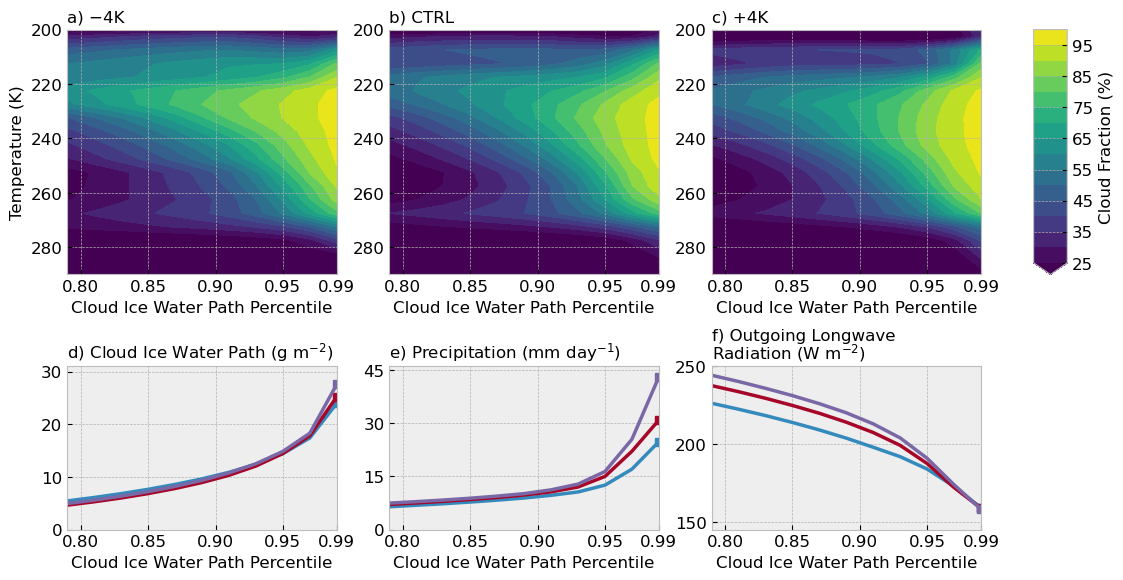

In [38]:
SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '12'
plt.rcParams['xtick.labelsize'] = '12'
plt.rcParams['ytick.labelsize'] = '12'
plt.rcParams['axes.labelsize'] = '12'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(2, 4, figure=fig,  width_ratios = [32, 32, 32, 4], height_ratios=[60,40])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.25, hspace=0.45)

cloud_ice_water_path_percentile_bins = np.linspace(0, 1, 51)

cloud_fraction_ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]

variable_ax = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]
# inset_axis = variable_ax[2].inset_axes([0.6, 0.55, 0.4, 0.45])

cbar_ax = fig.add_subplot(gs[0, 3])

for index, experiment in enumerate(coords.experiments.values):

    cloud_fraction_ax[index].set_title(
        f'{string.ascii_letters[index]}) {config.EXPERIMENT_DISPLAY_NAMES[experiment]}',
        loc='left',
        fontsize=12
    )
    im = cloud_fraction_ax[index].contourf(
        binned_cloud_fraction.cloud_ice_water_path_percentile,
        binned_cloud_fraction.temperature,
        100*binned_cloud_fraction.sel(experiment=experiment),
        # levels=np.linspace(0, 100, 21), 
        levels = np.arange(25, 100+5, 5),
        extend='min',
        cmap='viridis'
    )

    # cs = cloud_fraction_ax[index].contour(
    #     binned_cloud_fraction.cloud_ice_water_path_percentile,
    #     binned_cloud_fraction.temperature,
    #     100*binned_cloud_fraction.sel(experiment=experiment),
    #     levels=[95], 
    #     colors='k',
    #     linestyles='--',
    #     linewidths=1
    # )
    # cloud_fraction_ax[index].clabel(cs, inline=True, fontsize=8)

    variable_ax[0].plot(
        multi_experiment_variables_binned['Cloud Ice Water Path'].cloud_ice_water_path_percentile,
        1000*multi_experiment_variables_binned['Cloud Ice Water Path'].sel(experiment=experiment),
        color=bmh_colors(index+1)
    )
    variable_ax[0].plot(
        multi_experiment_variables_binned['Cloud Ice Water Path'].cloud_ice_water_path_percentile[-1],
        1000*multi_experiment_variables_binned['Cloud Ice Water Path'].sel(experiment=experiment)[-1],
        color=bmh_colors(index+1),
        marker='s',
    )

    variable_ax[1].plot(
        multi_experiment_variables_binned['Precipitation'].cloud_ice_water_path_percentile,
        multi_experiment_variables_binned['Precipitation'].sel(experiment=experiment),
        color=bmh_colors(index+1),
        # ls='--'
    )
    variable_ax[1].plot(
        multi_experiment_variables_binned['Precipitation'].cloud_ice_water_path_percentile[-1],
        multi_experiment_variables_binned['Precipitation'].sel(experiment=experiment)[-1],
        color=bmh_colors(index+1),
        marker='s',
    )

    variable_ax[2].plot(
        multi_experiment_variables_binned['Outgoing Longwave Radiation'].cloud_ice_water_path_percentile,
        multi_experiment_variables_binned['Outgoing Longwave Radiation'].sel(experiment=experiment),
        color=bmh_colors(index+1),
        ls='-'
    )
    variable_ax[2].plot(
        multi_experiment_variables_binned['Outgoing Longwave Radiation'].cloud_ice_water_path_percentile[-1],
        multi_experiment_variables_binned['Outgoing Longwave Radiation'].sel(experiment=experiment)[-1],
        color=bmh_colors(index+1),
        marker='s',
    )
    # inset_axis.plot(
    #     multi_experiment_variables_binned['Outgoing Longwave Radiation'].cloud_ice_water_path_percentile,
    #     multi_experiment_variables_binned['Outgoing Longwave Radiation'].sel(experiment=experiment),
    #     color=bmh_colors(index+1),
    #     ls='-'
    # )

cloud_fraction_ax[0].set_ylabel('Temperature (K)')

variable_ax[0].set_title(r'd) Cloud Ice Water Path (g m$^{-2}$)', loc='left', fontsize=12)
variable_ax[0].set_ylim(0, 31)
variable_ax[1].set_title(r'e) Precipitation (mm day$^{-1}$)', loc='left', fontsize=12)
variable_ax[1].set_ylim(0, 46)
variable_ax[1].set_yticks(np.arange(0, 60, 15))
variable_ax[2].set_title('f) Outgoing Longwave \nRadiation (W m$^{-2}$)', loc='left', fontsize=12, linespacing=0.9)
variable_ax[2].set_ylim(145, 250)

ciwp_min = 0.79
ciwp_max = 0.99
# ciwp_max = 1

# inset_axis.set_xlim(0, 0.8)
# inset_axis.set_ylim(240, 320)
# inset_axis.set_yticks([250, 300])

for axis in cloud_fraction_ax:
    axis.set_xlim(ciwp_min, ciwp_max)
    # axis.set_xticks(np.arange(0.8, ciwp_max+0.05, 0.05))
    axis.set_xticks([0.80, 0.85, 0.90, 0.95, 0.99])
    axis.set_xlabel('Cloud Ice Water Path Percentile')
    axis.set_ylim(200, 290)
    axis.invert_yaxis()

for axis in variable_ax:
    axis.set_xlim(ciwp_min, ciwp_max)
    axis.set_xticks([0.80, 0.85, 0.90, 0.95, 0.99])
    # axis.set_xticks(np.arange(0.8, ciwp_max+0.05, 0.05))
    axis.set_xlabel('Cloud Ice Water Path Percentile')

cbar = fig.colorbar(im, cax=cbar_ax)
# cbar.ax.axhline(y=95, color='k', lw=1, ls='--')
cbar.set_label('Cloud Fraction (%)')

output_filename = f"Cloud Fraction binned by Temperature and Cloud Ice Water Path - Percentile (zoomed)"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

In [ ]:
'''
- Temperature
- Moisture
- Precipitation
- Geopotential
- Outgoing Longwave Radiation
- Zonal Wind
- Meridional Wind
- Vertical Wind
- Cloud Ice Water Content
- Cloud Fraction
- Budget Terms
- Vertical MSE Advection
- Vertical DSE Advection
'''

In [ ]:
cloud_ice_water_path_bins = np.linspace(0, 1, 51)
cloud_ice_water_path_bins = np.arange(0, 75, 5)
temperature_bins = np.arange(190, 310, 5)
latitude_bounds = slice(-15,15)

multi_experiment_variables_binned = {}

logger.info("Bin Variables by CIWP")
for variable in ['Outgoing Longwave Radiation', 'Precipitation', 'Cloud Ice Water Path']:
    logger.info(f"    {variable}")
    multi_experiment_variables_binned[variable] = xr.DataArray(
        data=np.zeros((len(coords.experiments), len(cloud_ice_water_path_bins)-1)),
        dims=['experiment', 'cloud_ice_water_path'],
        coords={'experiment':coords.experiments, 'cloud_ice_water_path':0.5*(cloud_ice_water_path_bins[1:]+cloud_ice_water_path_bins[:-1])}
    )

    for index, experiment in enumerate(coords.experiments.values):
        mask = (
            ~np.isnan(multi_experiment_variables_subset['Cloud Ice Water Path'].sel(experiment=experiment, lat=latitude_bounds)) 
            & ~np.isnan(multi_experiment_variables_subset[variable].sel(experiment=experiment, lat=latitude_bounds))
        )

        [variables_binned_by_experiment, bin_edges, binnumber] = stats.binned_statistic(
            x=multi_experiment_variables_subset['Cloud Ice Water Path'].sel(experiment=experiment, lat=latitude_bounds).where(mask, drop=True).values.flatten(),
            values = multi_experiment_variables_subset[variable].sel(experiment=experiment, lat=latitude_bounds).where(mask, drop=True).values.flatten(),
            bins=cloud_ice_water_path_bins
        )
        multi_experiment_variables_binned[variable][index, :] = variables_binned_by_experiment

logger.info("Finished")

In [ ]:
binned_cloud_fraction = xr.DataArray(
    data=np.zeros((len(coords.experiments), len(temperature_bins)-1, len(cloud_ice_water_path_bins)-1)),
    dims=("experiment", "temperature", "cloud_ice_water_path"),
    coords={
        "experiment": coords.experiments,
        "temperature": 0.5 * (temperature_bins[:-1] + temperature_bins[1:]),
        "cloud_ice_water_path": 0.5 * (cloud_ice_water_path_bins[:-1] + cloud_ice_water_path_bins[1:]),
    },
    name="cloud_fraction_binned"
)

stacked_cloud_ice_water_path = 1000*multi_experiment_variables_subset['Cloud Ice Water Path'].expand_dims(plev=coords.pressure_levels).sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

# stacked_temperature = multi_experiment_variables_subset['Temperature'].drop_sel(time=coords.missing_days, errors='ignore').sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

# stacked_cloud_fraction = multi_experiment_variables_subset['Cloud Fraction'].drop_sel(time=coords.missing_days, errors='ignore').sel(lat=latitude_bounds, plev=slice(100, 950)).stack(samples=('time', 'plev', 'lat', 'lon'))

logger.info("Bin Cloud Fraction by CIWP and Temperature")
for index, experiment in enumerate(coords.experiments.values):
    logger.info(f"    Experiment {config.EXPERIMENT_DISPLAY_NAMES[experiment]}...")

    cloud_ice_water_path_digitized = np.digitize(stacked_cloud_ice_water_path.sel(experiment=experiment), bins=cloud_ice_water_path_bins, right=True)
    temperature_digitized = np.digitize(stacked_temperature.sel(experiment=experiment), bins=temperature_bins, right=True)
    binned_cloud_fraction[index] = np.array(
        [
            [
                stacked_cloud_fraction.sel(experiment=experiment)[(temperature_digitized == i) & (cloud_ice_water_path_digitized == j)].mean(dim='samples', skipna=True) 
                for i in range(1, len(temperature_bins))
                ] for j in range(1, len(cloud_ice_water_path_bins))
            ]
    ).T

logger.info("Finished")

In [ ]:
SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['font.size'] = '12'
plt.rcParams['xtick.labelsize'] = '12'
plt.rcParams['ytick.labelsize'] = '12'
plt.rcParams['axes.labelsize'] = '12'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = GridSpec(2, 4, figure=fig,  width_ratios = [32, 32, 32, 4], height_ratios=[60,40])
gs.update(top=1, bottom=0, left=0, right=1, wspace=0.25, hspace=0.4)

cloud_ice_water_path_bins = np.linspace(0, 1, 51)

cloud_fraction_ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]

variable_ax = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]

cbar_ax = fig.add_subplot(gs[0, 3])

for index, experiment in enumerate(coords.experiments.values):

    cloud_fraction_ax[index].set_title(
        f'{string.ascii_letters[index]}) {config.EXPERIMENT_DISPLAY_NAMES[experiment]}',
        loc='left',
        fontsize=12
    )
    # im = cloud_fraction_ax[index].contourf(
    #     binned_cloud_fraction.cloud_ice_water_path_percentile,
    #     binned_cloud_fraction.temperature,
    #     100*binned_cloud_fraction.sel(experiment=experiment),
    #     # extent=[cloud_ice_water_path_bins[0],cloud_ice_water_path_bins[-1],temperature_bins[0], temperature_bins[-1]],
    #     # [xedges[experiment][0],xedges[experiment][-1],yedges[experiment][0],yedges[experiment][-1]]
    #     levels=np.linspace(0, 100, 11), 
    #     cmap='viridis'
    #     # cmap=config.EXPERIMENT_CMAPS[experiment]
    # )
    im = cloud_fraction_ax[index].pcolormesh(
        cloud_ice_water_path_bins,
        temperature_bins,
        100*binned_cloud_fraction.sel(experiment=experiment),
        # extent=[cloud_ice_water_path_bins[0],cloud_ice_water_path_bins[-1],temperature_bins[0], temperature_bins[-1]],
        # [xedges[experiment][0],xedges[experiment][-1],yedges[experiment][0],yedges[experiment][-1]]
        # levels=np.linspace(0, 100, 11), 
        cmap='viridis'
        # cmap=config.EXPERIMENT_CMAPS[experiment]
    )
    cs = cloud_fraction_ax[index].contour(
        binned_cloud_fraction.cloud_ice_water_path,
        binned_cloud_fraction.temperature,
        100*binned_cloud_fraction.sel(experiment=experiment),
        levels=[95], 
        colors='k',
        linestyles='--',
        linewidths=1
    )
    cloud_fraction_ax[index].clabel(cs, inline=True, fontsize=8)

    # variable_ax[0].plot(
    #     multi_experiment_variables_binned['Cloud Ice Water Path'].cloud_ice_water_path,
    #     1000*multi_experiment_variables_binned['Cloud Ice Water Path'].sel(experiment=experiment),
    #     color=bmh_colors(index+1)
    # )

    # variable_ax[1].plot(
    #     multi_experiment_variables_binned['Precipitation'].cloud_ice_water_path,
    #     multi_experiment_variables_binned['Precipitation'].sel(experiment=experiment),
    #     color=bmh_colors(index+1)
    # )

    # variable_ax[2].plot(
    #     multi_experiment_variables_binned['Outgoing Longwave Radiation'].cloud_ice_water_path,
    #     multi_experiment_variables_binned['Outgoing Longwave Radiation'].sel(experiment=experiment),
    #     color=bmh_colors(index+1)
    # )

    variable_ax[0].step(
        cloud_ice_water_path_bins[1:],
        1000*multi_experiment_variables_binned['Cloud Ice Water Path'].sel(experiment=experiment),
        color=bmh_colors(index+1)
    )

    variable_ax[1].step(
        cloud_ice_water_path_bins[1:],
        multi_experiment_variables_binned['Precipitation'].sel(experiment=experiment),
        color=bmh_colors(index+1)
    )

    variable_ax[2].step(
        cloud_ice_water_path_bins[1:],
        multi_experiment_variables_binned['Outgoing Longwave Radiation'].sel(experiment=experiment),
        color=bmh_colors(index+1)
    )

cloud_fraction_ax[0].set_ylabel('Temperature (K)')

variable_ax[0].set_title(r'd) Cloud Ice Water Path (g m$^{-2}$)', loc='left', fontsize=12)
variable_ax[1].set_title(r'e) Precipitation (mm day$^{-1}$)', loc='left', fontsize=12)
variable_ax[2].set_title(r'f) Outgoing Longwave Radiation (W m$^{-2}$)', loc='left', fontsize=12)

variable_ax[0].set_ylim(0, 30)
variable_ax[1].set_ylim(0, 45)
variable_ax[2].set_yticks(np.arange(150, 280, 20))
variable_ax[2].set_ylim(150, 260)

variable_ax[2].invert_yaxis()

for axis in cloud_fraction_ax:
    axis.set_xlim(0, 70)
    # axis.set_xticks(np.arange(ciwp_min, 1.05, 0.05))
    axis.set_xlabel('Cloud Ice Water Path')

    axis.set_ylim(200, 290)
    axis.invert_yaxis()

for axis in variable_ax:
    axis.set_xlim(0, 70)
    # axis.set_xticks(np.arange(ciwp_min, 1.05, 0.05))
    axis.set_xlabel('Cloud Ice Water Path')

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.axhline(y=95, color='k', lw=1, ls='--')
cbar.set_label('Cloud Fraction (%)')

output_filename = f"Cloud Fraction binned by Temperature and Cloud Ice Water Path"
logger.info(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms")
logger.info(f"Output filename: {output_filename}")

if SAVE_FIG:
    logger.info(f"{'Saving...':<{config.SEP_WIDTH-1}}")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    logger.info("✔ Saved successfully")
else:
    logger.info("Not saving")

plt.show()

In [ ]:
binned_cloud_fraction.sel(experiment='0K').plot()

# Emissivity

In [ ]:
olr_mask = (
    multi_experiment_variables_subset['Outgoing Longwave Radiation']
    <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon'])
)

# mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     >= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.8, dim=['time', 'lat', 'lon'])
# )

# mask = multi_experiment_variables_subset['Precipitation'] >= multi_experiment_variables_subset['Precipitation'].sel(lat=slice(-15,15)).quantile(0, dim=['time', 'lat', 'lon'])

# cloud_fraction_mask = cloud_fraction_at_220K >= cloud_fraction_at_220K.quantile(0.8, dim=['time', 'lat', 'lon'])
# mask = cloud_fraction_at_220K <= cloud_fraction_at_220K.quantile(0.2, dim=['time', 'lat', 'lon'])

mask = olr_mask 

liquid_water_paths = xr.DataArray(
    np.logspace(0, 4, 100),
    dims=['liquid_water_path'],
    coords={'liquid_water_path': np.logspace(0, 4, 100)}
)
stephens_param_down = 1 - np.exp(-0.158*liquid_water_paths)
stephens_param_up = 1 - np.exp(-0.13*liquid_water_paths)

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
ax = fig.add_subplot()

ax.plot(liquid_water_paths, stephens_param_down, color='k', ls=':', label='Downward Flux')
ax.plot(liquid_water_paths, stephens_param_up, color='k', ls='--', label='Upward Flux')
for index, experiment in enumerate(coords.experiments.values):
    ax.axvline(
        1000*multi_experiment_variables_subset['Cloud Liquid Water Path'].where(mask).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']).sel(experiment=experiment),
        color=bmh_colors(index+1),
        label = config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )
ax.set_xlabel(r'Liquid Water Path (g m$^{-2}$)')
ax.set_ylabel('Emissivity')
ax.set_xlim(1, 10000)
ax.set_xticks([1, 10, 100, 1000, 10000])
ax.set_xscale('log')
ax.legend(loc='lower right')

output_filename = 'Emissivity as a function of Liquid Water Path'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
diffusivity_factor = 1.66
effective_radius = 50
# lambda_vals = np.array([4.1,5,6.1,7,8.1,9.1,10,11.1,12.2,14.1,16.1,18.2,20,25,31,37,50,75,100,167])
# alpha = np.array(
#     [0.0048,0.0054,0.0005,0.0013,0.003,0.0038,0.0043,0.0003,-0.0013,-0.002,0,0.0028,0.0044,0.0077,0.0074,0.0043,-0.0004,0.0072,0.011,0.0099])
# gamma = np.array(
#     [0.69,0.626,1.279,1.193,1.021,0.949,0.911,1.29,1.452,1.558,1.388,1.099,0.92,0.366,0.603,1.014,1.604,0.926,0.34,0.001]
# )

i = [1,2,3,4,5]
alpha = np.array([0.002, 0.0016, 0.0003, 0.0068, 0.0036])
gamma = np.array([1.118, 1.166, 1.338, 0.600, 1.136])

weights = xr.DataArray(
    data=np.array([0.040, 0.200, 0.340, 0.281, 0.139]),
    dims=['wavelength_band'],
    coords={'wavelength_band': i}
)

kappa = xr.DataArray(
    data=(alpha + gamma/effective_radius),
    dims=['wavelength_band'],
    coords={'wavelength_band': i}
)
ice_water_paths = xr.DataArray(
    data=np.linspace(0, 300, 100),
    dims=["ice_water_path"],
    coords={'ice_water_path': np.linspace(0, 300, 100)}
)

parameterized_emissivity = (1 - np.exp(-diffusivity_factor*kappa*ice_water_paths)).weighted(weights).mean(dim='wavelength_band')

# olr_mask = (
#     multi_experiment_variables_subset['Outgoing Longwave Radiation']
#     <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon'])
# )

_, CIWC_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Ice Water Content'], 220)
# ciwc_mask = (
#     CIWC_at_220K <= CIWC_at_220K.quantile(.1, dim=['time', 'lat', 'lon'])
# )

olr_mask = (
    multi_experiment_variables_subset['Outgoing Longwave Radiation']
    <= multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon'])
)

ciwc_mask = (
    CIWC_at_220K >= CIWC_at_220K.quantile(.9999, dim=['time', 'lat', 'lon'])
)

mask = olr_mask# * ciwc_mask 

SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
ax = fig.add_subplot()

ax.plot(ice_water_paths, parameterized_emissivity, color='k', ls='-')
for index, experiment in enumerate(coords.experiments.values):
    ax.axvline(
        1000*multi_experiment_variables_subset['Cloud Ice Water Path'].where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']).sel(experiment=experiment),
        color=bmh_colors(index+1),
        label = rf"{config.EXPERIMENT_DISPLAY_NAMES[experiment]:<6s} (0.005th Percentile OLR = {multi_experiment_variables_subset['Outgoing Longwave Radiation'].quantile(0.005, dim=['time', 'lat', 'lon']).sel(experiment=experiment).values:0.0f} W m$^{{-2}}$)",
    )

ax.set_xlabel(r'Ice Water Path (g m$^{-2}$)')
ax.set_ylabel('Emissivity')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')

output_filename = 'Emissivity as a function of Ice Water Path'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
estimated_ice_emissivity = 1 - np.exp(-diffusivity_factor*kappa*1000*multi_experiment_variables_subset['Cloud Ice Water Path'].where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon'])).weighted(weights).mean(dim='wavelength_band')

estimated_liquid_emissivity = 1 - np.exp(-0.13*1000*multi_experiment_variables_subset['Cloud Liquid Water Path'].where(mask, drop=True).sel(lat=slice(-15,15)).mean(dim=['time', 'lat', 'lon']))

# pressure_at_220K, CIWC_at_220K = temperature_level_interpolation(multi_experiment_variables_subset['Cloud Ice Water Content'], 220)

cloud_top_ice_emission = (
    estimated_ice_emissivity 
    * config.STEFAN_BOLTZMANN_CONSTANT 
    * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None), plev=0))**4
)

cloud_top_liquid_emission = (
    estimated_liquid_emissivity 
    * config.STEFAN_BOLTZMANN_CONSTANT 
    * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None), plev=0))**4
)

In [ ]:

weights = xr.DataArray(
    data=np.array([0.040, 0.200, 0.340, 0.281, 0.139]),
    dims=['weights'],
    coords={'weights':weights}
)

kappa = xr.DataArray(
    data=alpha + gamma/effective_radius,
    dims=['weights'],
    coords={'weights':weights}
)

emissivity_by_wavelength = 1 - np.exp(-diffusivity_factor*kappa*1000*multi_experiment_variables_subset['Cloud Ice Water Path'])
cloud_ice_longwave_emissivity = emissivity_by_wavelength.weighted(weights).mean(dim='weights')

pressure_at_220K, CIWC_at_22K = temperature_level_interpolation('Cloud Ice Water Content', 240)

cloud_top_ice_emission = cloud_ice_longwave_emissivity * config.STEFAN_BOLTZMANN_CONSTANT * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(plev=pressure_at_220K, method='nearest'))**4

cloud_water_longwave_emissivity = 1 - np.exp(-0.13*1000*multi_experiment_variables_subset['Cloud Liquid Water Path'])
cloud_top_water_emission = cloud_water_longwave_emissivity * config.STEFAN_BOLTZMANN_CONSTANT * (multi_experiment_variables_subset['Temperature'].isel(time=slice(1, None)).sel(plev=pressure_at_220K, method='nearest'))**4

In [ ]:
SAVE_FIG = False
PLOT_MODE = "slides"
FIG_LAYOUT = 'twocol'
plt.style.use('bmh')
set_plot_mode(PLOT_MODE)
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig = plt.figure(figsize=get_figsize(PLOT_MODE, FIG_LAYOUT))
gs = fig.add_gridspec(1, 2, wspace=0.3)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95)

ax = []
ax.append(fig.add_subplot(gs[0]))
ax.append(fig.add_subplot(gs[1]))

left, bottom, width, height = [0.255, 0.65, 0.17, 0.25]
inset_axis = fig.add_axes([left, bottom, width, height])

olr_hist = multi_experiment_variables_subset['Outgoing Longwave Radiation'].stats.histogram(dims=['time', 'lat', 'lon'], bins=100)
precip_hist = multi_experiment_variables_subset['Precipitation'].units.to_energy_units().stats.histogram(dims=['time', 'lat', 'lon'], bins=50)

for index, experiment in enumerate(coords.experiments.values):
    ax[0].stairs(
        olr_hist['counts'].sel(experiment=experiment),
        olr_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )
    
    ax[1].stairs(
        precip_hist['counts'].sel(experiment=experiment),
        precip_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth=2,
    )

    ax[1].axvline(
        multi_experiment_variables_subset['Precipitation'].units.to_energy_units().sel(experiment=experiment).quantile(0.9999, dim=['time', 'lat', 'lon']),
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )

    # ax[0].axvline(
    #     multi_experiment_variables_subset['Outgoing Longwave Radiation'].sel(experiment=experiment).quantile(0.005, dim=['time', 'lat', 'lon']),
    #     color=bmh_colors(index+1),
    #     label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    # )

    inset_axis.stairs(
        olr_hist['counts'].sel(experiment=experiment),
        olr_hist['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )

    inset_axis.axvline(
        multi_experiment_variables_subset['Outgoing Longwave Radiation'].sel(experiment=experiment).quantile(0.005, dim=['time', 'lat', 'lon']),
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment]
    )

ax[0].set_xlabel(r'OLR (W m$^{-2}$)')
ax[1].set_xlabel(r'$L_v$ P (W m$^{-2}$)')

inset_axis.set_xlim([120, 180])
inset_axis.set_xticks([180, 160, 140, 120])
inset_axis.set_ylim([0, 75000])
inset_axis.set_yticks([25000, 50000, 75000])
inset_axis.invert_xaxis()
inset_axis.tick_params(labelsize=12)

# ax0_percentile = inset_axis.secondary_xaxis('top')
# ax0_percentile.set_xticks(
#     olr_percentile_ticks,
#     labels=format_axis_labels(olr_percentile_levels)
#     )
# ax0_percentile.set_xlabel('OLR percentile', fontsize=12)
# ax0_percentile.xaxis.set_ticks_position('top')
# ax0_percentile.xaxis.set_label_position('top')
# ax0_percentile.tick_params(axis='x', labelsize=10, pad=2)
# ax0_percentile.set_xlim(inset_axis.get_xlim())
# if inset_axis.xaxis_inverted():
#     ax0_percentile.invert_xaxis()

# ax[1].loglog()
ax[1].set_yscale('log')
ax[0].invert_xaxis()

output_filename = 'OLR & Precipitation Histograms'
print(f"Output directory: {config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/")
print(f"Output filename: {output_filename}")
if SAVE_FIG:
    print(f"{f'Saving...':<{config.SEP_WIDTH-1}}", end="")
    plt.savefig(
        f"{config.AQUAPLANET_OUTPUT_DIRECTORY}/histograms/{output_filename}.svg",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")

plt.show()

In [ ]:
tcc_histogram = multi_experiment_variables_subset['Total Cloud Condensate'].dropna(dim='time').stats.histogram(dims=['time', 'lat', 'lon'], bins=100)
for index, experiment in enumerate(coords.experiments.values):
    plt.stairs(
        tcc_histogram['counts'].sel(experiment=experiment),
        tcc_histogram['bin_edges'],
        alpha=0.5,
        color=bmh_colors(index+1),
        label=config.EXPERIMENT_DISPLAY_NAMES[experiment],
        zorder=4-index,
        linewidth = 4
    )
plt.semilogy()